In [1]:
### Harp Usage Example

In [1]:
import os
import harp
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cmcrameri import cm

In [ ]:
dir_path = "./"
test_file = "S5P_OFFL_L2__SO2____20210412T151823_20210412T165953_18121_01_020104_20210414T175908.nc"
filename_l2 = "S5P_RPRO_L2__CH4____20190219T181651_20190219T195822_07014_03_020400_20221120T110926.nc"
filename_l1 = "S5P_OFFL_L1B_IR_SIR_20230426T175505_20230426T193636_28678_03_020100_20230426T212156.nc"

#### Example

In [24]:
product = harp.import_product(os.path.join(dir_path, test_file))
print(product)

source product = 'S5P_OFFL_L2__SO2____20210412T151823_20210412T165953_18121_01_020104_20210414T175908.nc'

int scan_subindex {time=1877400}
double datetime_start {time=1877400} [seconds since 2010-01-01]
float datetime_length [s]
int orbit_index
long validity {time=1877400}
float latitude {time=1877400} [degree_north]
float longitude {time=1877400} [degree_east]
float latitude_bounds {time=1877400, 4} [degree_north]
float longitude_bounds {time=1877400, 4} [degree_east]
float sensor_latitude {time=1877400} [degree_north]
float sensor_longitude {time=1877400} [degree_east]
float sensor_altitude {time=1877400} [m]
float solar_zenith_angle {time=1877400} [degree]
float solar_azimuth_angle {time=1877400} [degree]
float sensor_zenith_angle {time=1877400} [degree]
float sensor_azimuth_angle {time=1877400} [degree]
double pressure {time=1877400, vertical=34} [Pa]
float SO2_column_number_density {time=1877400} [mol/m^2]
float SO2_column_number_density_uncertainty_random {time=1877400} [mol/m^2

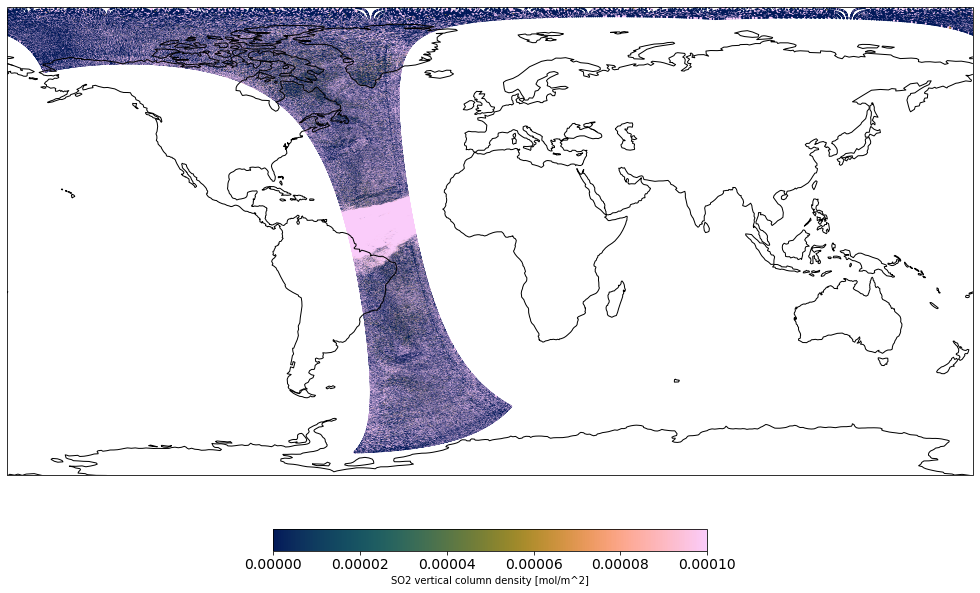

In [29]:
SO2val = product.SO2_column_number_density.data
SO2units = product.SO2_column_number_density.unit
SO2description = product.SO2_column_number_density.description

latc = product.latitude.data
lonc = product.longitude.data

colortable = cm.batlow
vmin = 0
vmax = 0.0001

fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.PlateCarree())


img = plt.scatter(
    lonc,
    latc,
    c=SO2val,
    vmin=vmin,
    vmax=vmax,
    cmap=colortable,
    s=1,
    transform=ccrs.PlateCarree(),
)

ax.coastlines()

cbar = fig.colorbar(img, ax=ax, orientation="horizontal", fraction=0.04, pad=0.1)
cbar.set_label(f"{SO2description} [{SO2units}]")
cbar.ax.tick_params(labelsize=14)
plt.show()

### TROPOMI L2

#### Read data

In [30]:
product = harp.import_product(os.path.join(dir_path, filename_l2))
print(product)
print(product.CH4_column_volume_mixing_ratio_dry_air)
print(product.CH4_column_volume_mixing_ratio_dry_air.data)
print(product.CH4_column_volume_mixing_ratio_dry_air.unit)

source product = 'S5P_RPRO_L2__CH4____20190219T181651_20190219T195822_07014_03_020400_20221120T110926.nc'

int scan_subindex {time=697675}
double datetime_start {time=697675} [seconds since 2010-01-01]
float datetime_length [s]
int orbit_index
long validity {time=697675}
float latitude {time=697675} [degree_north]
float longitude {time=697675} [degree_east]
float latitude_bounds {time=697675, 4} [degree_north]
float longitude_bounds {time=697675, 4} [degree_east]
float sensor_latitude {time=697675} [degree_north]
float sensor_longitude {time=697675} [degree_east]
float sensor_altitude {time=697675} [m]
float solar_zenith_angle {time=697675} [degree]
float solar_azimuth_angle {time=697675} [degree]
float sensor_zenith_angle {time=697675} [degree]
float sensor_azimuth_angle {time=697675} [degree]
float altitude_bounds {time=697675, vertical=12, 2} [m]
float pressure_bounds {time=697675, vertical=12, 2} [Pa]
float surface_altitude {time=697675} [m]
float surface_altitude_uncertainty {time

#### Data feature

In [31]:
print(
    product.latitude.data.shape,
    product.longitude.data.shape,
    product.CH4_column_volume_mixing_ratio_dry_air.data.shape,
)

(697675,) (697675,) (697675,)


In [32]:
product.CH4_column_volume_mixing_ratio_dry_air.data[:10]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan], dtype=float32)

#### Plot a single orbit data on the map

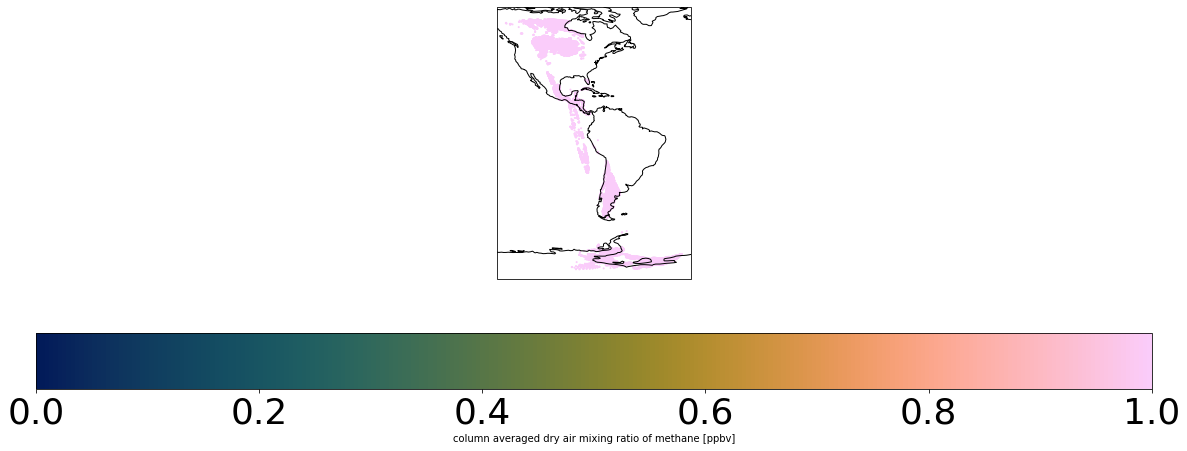

In [35]:
CH4val = product.CH4_column_volume_mixing_ratio_dry_air.data
CH4units = product.CH4_column_volume_mixing_ratio_dry_air.unit
CH4description = product.CH4_column_volume_mixing_ratio_dry_air.description

latc = product.latitude.data
lonc = product.longitude.data

colortable = cm.batlow
vmin = 0
vmax = 1

fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
img = plt.scatter(
    lonc,
    latc,
    c=CH4val,
    vmin=vmin,
    vmax=vmax,
    cmap=colortable,
    s=1,
    transform=ccrs.PlateCarree(),
)
ax.coastlines()
cbar = fig.colorbar(img, ax=ax, orientation="horizontal", fraction=0.4, pad=0.1)
cbar.set_label(f"{CH4description} [{CH4units}]")
cbar.ax.tick_params(labelsize=36)
plt.show()

#### Operation

<class 'str'>
latitude>-20;latitude<20;CH4_column_volume_mixing_ratio_dry_air_validity>50;keep(datetime_start, latitude, longitude, CH4_column_volume_mixing_ratio_dry_air)
source product = 'S5P_RPRO_L2__CH4____20190219T181651_20190219T195822_07014_03_020400_20221120T110926.nc'
history = "2023-05-04T11:44:35Z [harp-1.13] harp.import_product('/Users/xudi/Desktop/IC/research/data/TPOROMI/dataset/S5P_RPRO_L2__CH4____20190219T181651_20190219T195822_07014_03_020400_20221120T110926.nc',operations='latitude>-20;latitude<20;CH4_column_volume_mixing_ratio_dry_air_validity>50;keep(datetime_start, latitude, longitude, CH4_column_volume_mixing_ratio_dry_air)')"

double datetime_start {time=1985} [seconds since 2010-01-01]
float latitude {time=1985} [degree_north]
float longitude {time=1985} [degree_east]
float CH4_column_volume_mixing_ratio_dry_air {time=1985} [ppbv]



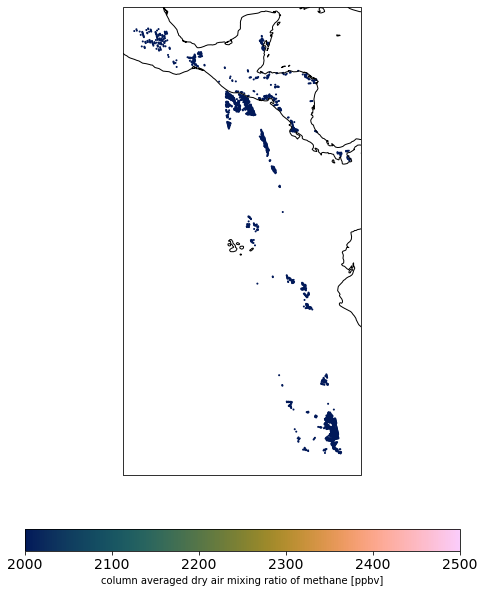

In [53]:
operations = ";".join(
    [
        "latitude>-20;latitude<20",
        "CH4_column_volume_mixing_ratio_dry_air_validity>50",
        "keep(datetime_start, latitude, longitude, CH4_column_volume_mixing_ratio_dry_air)",
        # "derive(CH4_column_volume_mixing_ratio_dry_air [DU])",
    ]
)
print(type(operations))
print(operations)

reduced_product = harp.import_product(os.path.join(dir_path, filename_l2), operations)
print(reduced_product)

CH4val = reduced_product.CH4_column_volume_mixing_ratio_dry_air.data
CH4units = reduced_product.CH4_column_volume_mixing_ratio_dry_air.unit
CH4description = reduced_product.CH4_column_volume_mixing_ratio_dry_air.description
latc = reduced_product.latitude.data
lonc = reduced_product.longitude.data

colortable = cm.batlow
vmin = 2000
vmax = 2500

fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
img = plt.scatter(
    lonc,
    latc,
    c=CH4val,
    vmin=vmin,
    vmax=vmax,
    cmap=colortable,
    s=1,
    transform=ccrs.PlateCarree(),
)
ax.coastlines()

cbar = fig.colorbar(img, ax=ax, orientation="horizontal", fraction=0.04, pad=0.1)
cbar.set_label(f"{CH4description} [{CH4units}]")
cbar.ax.tick_params(labelsize=14)
plt.show()

#### Regridding with HARP and plotting using pcolormesh

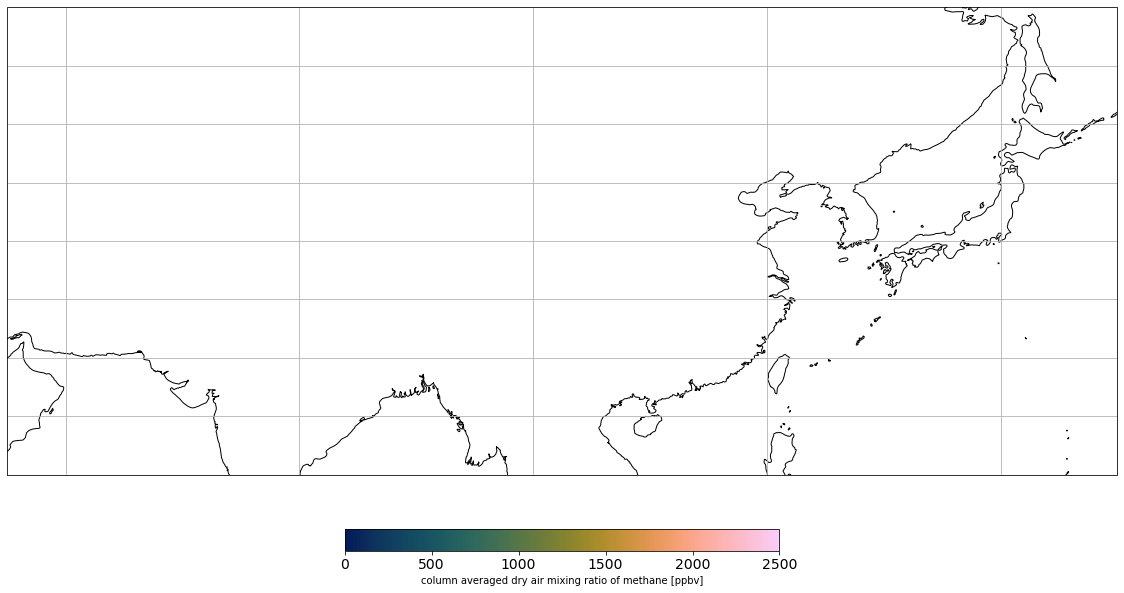

In [81]:
operations = ";".join(
    [
        "latitude>-20;latitude<25",
        "CH4_column_volume_mixing_ratio_dry_air_validity>50",
        "bin_spatial(801, 15, 0.05, 1001, 100, 0.05)",
        # "derive(CH4_column_volume_mixing_ratio_dry_air [DU])",
        "derive(latitude {latitude})",
        "derive(longitude {longitude})",
    ]
)

regridded_product = harp.import_product(os.path.join(dir_path, filename_l2), operations)
# print(regridded_product)
# print(regridded_product.latitude_bounds.data[:,0])
# print(regridded_product.longitude_bounds.data[:,1])
gridlat = np.append(
    regridded_product.latitude_bounds.data[:, 0],
    regridded_product.latitude_bounds.data[-1, 1],
)
gridlon = np.append(
    regridded_product.longitude_bounds.data[:, 0],
    regridded_product.latitude_bounds.data[-1, 1],
)


CH4val = regridded_product.CH4_column_volume_mixing_ratio_dry_air.data
CH4units = regridded_product.CH4_column_volume_mixing_ratio_dry_air.unit
CH4description = regridded_product.CH4_column_volume_mixing_ratio_dry_air.description
colortable = cm.batlow
vmin = 0
vmax = 2500


ig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
img = plt.pcolormesh(
    gridlon,
    gridlat,
    CH4val[0, :, :],
    vmin=vmin,
    vmax=vmax,
    cmap=colortable,
    transform=ccrs.PlateCarree(),
)
ax.coastlines()
ax.gridlines()

cbar = fig.colorbar(img, ax=ax, orientation="horizontal", fraction=0.04, pad=0.1)
cbar.set_label(f"{CH4description} [{CH4units}]")
cbar.ax.tick_params(labelsize=14)
plt.show()

### TROPOMI L1B

In [85]:
filename_l1 = "S5P_OFFL_L1B_RA_BD7_20230423T152847_20230423T171018_28634_03_020100_20230423T185524.nc"
product = harp.import_product(os.path.join(dir_path, filename_l1))

In [86]:
print(product)

source product = 'S5P_OFFL_L1B_RA_BD7_20230423T152847_20230423T171018_28634_03_020100_20230423T185524.nc'

int scan_subindex {time=896980}
double datetime {time=896980} [seconds since 2010-01-01]
int orbit_index
float latitude {time=896980} [degree_north]
float longitude {time=896980} [degree_east]
float latitude_bounds {time=896980, 4} [degree_north]
float longitude_bounds {time=896980, 4} [degree_east]
float sensor_latitude {time=896980} [degree_north]
float sensor_longitude {time=896980} [degree_east]
float sensor_altitude {time=896980} [m]
float solar_zenith_angle {time=896980} [degree]
float solar_azimuth_angle {time=896980} [degree]
float sensor_zenith_angle {time=896980} [degree]
float sensor_azimuth_angle {time=896980} [degree]
float wavelength {time=896980, spectral=480} [nm]
float photon_radiance {time=896980, spectral=480} [mol/(s.m^2.nm.sr)]
long index {time=896980}



In [97]:
print(product.latitude.data.shape, product.photon_radiance.data.shape)

(896980,) (896980, 480)


In [98]:
### wavelength
print(product.wavelength.data[0, :].min(), product.wavelength.data[0, :].max())

2300.4172 2342.524


In [ ]:
CH4L1val = product.photon_radiance.data
CH4L1val_total = np.array([0 for i in range(CH4L1val.shape[0])])
for dl in range(CH4L1val.shape[0]):
    CH4L1val_total[dl] = sum(CH4L1val[dl, :])
CH4L1units = product.photon_radiance.unit
CH4L1description = product.photon_radiance.description

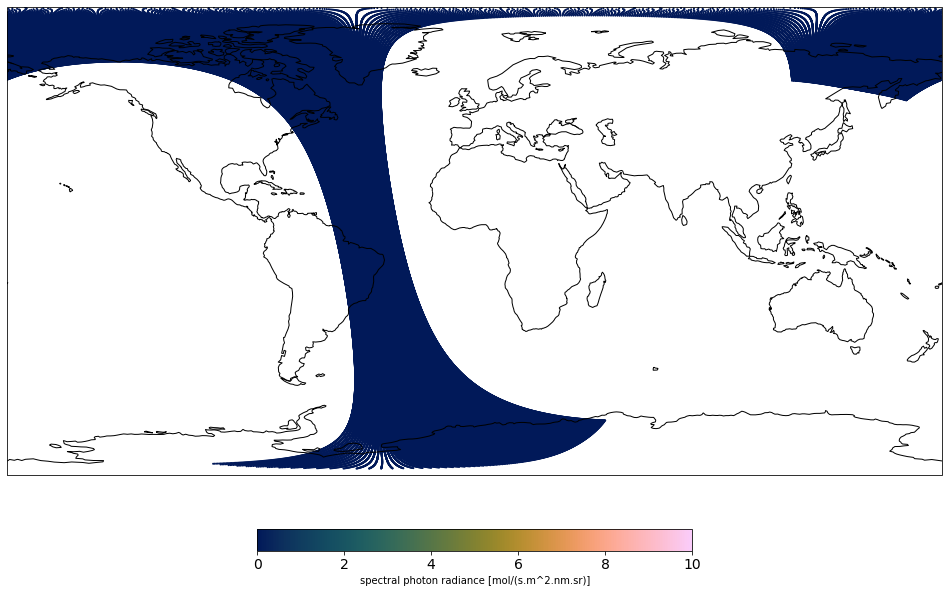

In [106]:
latc = product.latitude.data
lonc = product.longitude.data

colortable = cm.batlow
vmin = 0
vmax = 10

fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.PlateCarree())


img = plt.scatter(
    lonc,
    latc,
    c=CH4L1val_total,
    vmin=vmin,
    vmax=vmax,
    cmap=colortable,
    s=1,
    transform=ccrs.PlateCarree(),
)

ax.coastlines()

cbar = fig.colorbar(img, ax=ax, orientation="horizontal", fraction=0.04, pad=0.1)
cbar.set_label(f"{CH4L1description} [{CH4L1units}]")
cbar.ax.tick_params(labelsize=14)
plt.show()

In [107]:
CH4description, CH4L1units

('column averaged dry air mixing ratio of methane', 'mol/(s.m^2.nm.sr)')